# Ajustement matrice-libre (CG) + log-déterminant stochastique (`LLIterative`) vs Cholesky exact

## Contexte

`LLIterative` est l'alternative matrice-libre de `fit` à l'objectif exact
(`objective="LL"`) : chaque terme de la vraisemblance concentrée, sauf
$\log|R|$, est calculé par gradient conjugué (CG) au lieu d'une
factorisation de Cholesky dense en $O(n^3)$, et $\log|R|$ lui-même — le
seul terme que CG ne peut pas produire directement — est remplacé par une
estimation par **quadrature de Lanczos stochastique (SLQ)**. C'est la même
stratégie que l'inférence BBMM/Lanczos de GPyTorch (Gardner et al. 2018).

**Ce notebook est volontairement très détaillé et pédagogique** : on
part des bases (ce que calcule une vraisemblance de krigeage, pourquoi
c'est cher, ce qu'est Cholesky, ce qu'est le gradient conjugué) avant
d'aborder les points plus fins (pourquoi CG ne donne pas le
déterminant, l'astuce d'Hutchinson, la quadrature de Lanczos, les
réglages de convergence). Tout ici concerne `fit`/la vraisemblance ; le
prédicteur matrice-libre construit sur la même mécanique CG,
`predictIterative`, est volontairement hors-sujet — voir
[predictiterative_vs_cholesky.ipynb](predictiterative_vs_cholesky.ipynb)
pour cela (le §9 ci-dessous n'est qu'un paragraphe de renvoi).

Où se situe `LLIterative` par rapport aux autres objectifs de passage à
l'échelle :

- **`LLVecchia`/`LLNystrom`** échangent l'exactitude contre un $R$ moins
  cher : chaque évaluation coûte vraiment $O(n\cdot m^3)$/$O(n\cdot k^2)$
  — l'objectif lui-même approxime une covariance *différente, structurée*.
- **`LLIterative`** garde le *vrai* $R$ de bout en bout : $\hat\beta$,
  $\hat\sigma^2$ et la forme quadratique sont exacts à la tolérance de CG
  près, ce n'est pas une approximation structurelle. Chaque évaluation
  coûte toujours $O(n^2)$ par itération de CG (ou une construction dense
  en $O(n^2)$ suivie de produits matrice-vecteur BLAS-3 quand $R$ tient
  dans un budget mémoire) — cela ne réduit pas le coût du produit
  matrice-vecteur comme le font Vecchia/Nystrom. Le gain est d'éviter la
  factorisation en $O(n^3)$ et le facteur résident en $O(n^2)$, même
  logique que `predictIterative` mais appliquée à `fit`.

Voir [Iterative.md](Iterative.md) pour la référence complète de l'API —
ce notebook en est le compagnon exécutable et pédagogique, pas un
remplacement.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pylibkriging as lk
import warnings
warnings.filterwarnings('ignore')

lk.set_cuda_iterative_enabled(False)  # chemin CPU/OpenMP de bout en bout : l'histoire
                                      # numérique racontée ici est indépendante du backend
                                      # (les optimisations spécifiques CUDA de CHANGELOG.md
                                      # -- Lanczos résident sur device, compaction de
                                      # colonnes, précision mixte -- changent OÙ tournent
                                      # les calculs, pas CE QUI est calculé)

plt.rcParams['figure.figsize'] = (9, 4.2)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

np.random.seed(42)

## 1.0 Rappel : ce que calcule une vraisemblance de krigeage, et pourquoi c'est cher

Ajuster un modèle de krigeage (processus gaussien), c'est trouver les
paramètres de corrélation $\theta$ qui rendent les données observées
$y$ les plus "vraisemblables" possible sous le modèle. Sans entrer dans
la dérivation complète (voir [Kriging.md](Kriging.md)), la vraisemblance
concentrée (celle qu'on maximise en $\theta$, une fois $\hat\beta$ et
$\hat\sigma^2$ profilés analytiquement) a la forme générale

$$
\ell(\theta) \;=\; -\tfrac{1}{2}\log|R(\theta)| \;-\; \tfrac{n}{2}\log\hat\sigma^2(\theta) \;+\; \text{constante},
$$

où $R(\theta)$ est la matrice de corrélation $n\times n$ entre les $n$
points d'apprentissage (symétrique, définie positive, dense en général —
chaque paire de points a une corrélation non nulle), et où $\hat\beta$,
$\hat\sigma^2$ eux-mêmes s'obtiennent par les formules classiques des
moindres carrés généralisés (GLS), qui ont besoin de $R^{-1}F$ et
$R^{-1}y$ ($F$ étant la matrice de tendance, quelques colonnes
seulement).

**Deux ingrédients coûteux, donc, à extraire de $R$ à chaque $\theta$
essayé** :

1. résoudre des systèmes linéaires $R^{-1}F$, $R^{-1}y$ (pour
   $\hat\beta$/$\hat\sigma^2$ et la forme quadratique qu'ils contiennent) ;
2. calculer $\log|R|$ (le déterminant, en log, pour le terme de
   normalisation — sans lui, il serait trivial de "tricher" en gonflant
   $\theta$ pour rendre $R$ arbitrairement lisse).

$R$ est $n\times n$ : la stocker coûte $O(n^2)$ en mémoire, et toute
opération "generique" dessus (l'inverser, la factoriser) coûte $O(n^3)$
en temps. Pour $n$ petit à modéré c'est parfaitement gérable ; c'est
uniquement quand $n$ devient grand (au point que $O(n^2)$ de mémoire ou
$O(n^3)$ de temps deviennent prohibitifs) que la question "comment
obtenir ces deux ingrédients autrement" devient intéressante — c'est
exactement la raison d'être de `LLIterative`.

## 1.1 La méthode exacte : la factorisation de Cholesky

L'objectif exact (`objective="LL"`) résout les deux problèmes ci-dessus
d'un seul coup en factorisant $R = LL^\top$, où $L$ est triangulaire
inférieure (la **factorisation de Cholesky**, valable pour toute matrice
symétrique définie positive). Une fois $L$ calculée :

- **Résoudre $Rx=b$** devient deux résolutions triangulaires bon marché
  ($Ly=b$ puis $L^\top x=y$, chacune par substitution avant/arrière,
  $O(n^2)$ au lieu de $O(n^3)$) — beaucoup moins cher qu'inverser $R$
  directement.
- **$\log|R|$ est un sous-produit gratuit** : $\log|R| = 2\sum_i \log
  L_{ii}$ (le déterminant d'une matrice triangulaire est le produit de sa
  diagonale, et $\det(R)=\det(L)^2$).

Le coût de $L$ elle-même reste $O(n^3)$ en temps et $O(n^2)$ en mémoire
résidente (il faut stocker $L$ en entier pour s'en resservir). C'est
exact, déterministe, et donne les deux ingrédients d'un coup — mais c'est
précisément ce coût $O(n^3)$/$O(n^2)$ que `LLIterative` cherche à éviter
quand $n$ devient trop grand.

## 1.2 Le gradient conjugué (CG) : résoudre sans factoriser

**Le problème que CG résout** : trouver $x$ tel que $Rx=b$, mais **sans
jamais former, stocker ou factoriser $R$ explicitement** — seulement en
sachant calculer le produit $R\cdot v$ pour un vecteur $v$ quelconque (un
"produit matrice-vecteur", ou *matvec*). Pour une matrice de covariance,
ce produit peut se calculer directement à partir des coordonnées des
points et de $\theta$, sans jamais construire ni stocker la matrice
$n\times n$ complète — c'est ce qui rend l'approche "matrice-libre".

**L'idée de CG, intuitivement** (voir Hestenes & Stiefel 1952 pour la
théorie complète) : partant de $x=0$, l'algorithme améliore
itérativement son estimation en avançant le long de directions bien
choisies (construites à partir du résidu courant $r = b - Rx$), chaque
pas réduisant la norme du résidu. En arithmétique exacte, CG est garanti
d'atteindre la solution exacte en au plus $n$ pas ; en pratique, avec
l'arithmétique flottante et une matrice raisonnablement conditionnée,
il atteint une précision largement suffisante en beaucoup **moins** de
$n$ pas — et c'est précisément ce qui rend la méthode intéressante :
on fixe une **tolérance** (résidu relatif cible, `cg_tol`) et on
s'arrête dès qu'elle est atteinte, sans jamais aller jusqu'à $n$.

**Pourquoi c'est moins cher que Cholesky, quand ça marche bien** :
chaque itération ne coûte qu'un produit matrice-vecteur ($O(n^2)$ si fait
densément, moins si on exploite une structure), et rien n'a besoin
d'être stocké à part quelques vecteurs de taille $n$ (pas de facteur
$n\times n$ résident). Si la convergence a lieu en un nombre d'itérations
petit devant $n$, le coût total reste bien en-deçà de $O(n^3)$, et
l'empreinte mémoire reste $O(n)$ au lieu de $O(n^2)$ — c'est tout le pari
de `LLIterative`. §2 à §4 ci-dessous creusent précisément la question
"combien d'itérations, dans quelles conditions".

**Un point important pour la suite** : `LLIterative` ne résout jamais
une seule colonne à la fois. Un seul appel CG **groupé** ("batché")
résout $R^{-1}\cdot[F\mid y]$ simultanément ($F$ ayant quelques colonnes
seulement, plus $y$) : toutes les colonnes avancent en lock-step, en
partageant le même produit matrice-vecteur à chaque itération — donc le
coût d'une itération ne dépend presque pas du nombre de colonnes
résolues ensemble tant qu'on reste à matrice $R$ fixée. $\hat\beta$,
$\hat\sigma^2$ et la forme quadratique suivent ensuite exactement les
mêmes formules que l'objectif de Cholesky ; seule la façon d'obtenir
$R^{-1}(\cdot)$ diffère, et CG la rend exacte à sa tolérance de
convergence près — pas une approximation structurelle.

## 1.3 Pourquoi CG ne donne pas $\log|R|$ (et pourquoi il faut une autre méthode)

Résoudre $Rx=b$ ne révèle rien, directement, sur $\det(R)$ : ce sont deux
questions différentes ("quel $x$ satisfait cette équation" contre
"comment $R$ change-t-elle les volumes / quel est le produit de ses
valeurs propres"). Cholesky obtient les deux à partir de la **même**
factorisation ($L$ sert à la fois aux résolutions et donne le
déterminant via sa diagonale) — mais CG ne voit jamais $R$ autrement
qu'à travers des produits matrice-vecteur, et n'extrait jamais la
structure spectrale (valeurs propres) dont on aurait besoin pour un
déterminant.

Il faut donc une **méthode séparée**, qui elle aussi n'accède à $R$ que
par produits matrice-vecteur (sinon on perd tout l'intérêt d'être
matrice-libre), pour estimer $\log|R|$. C'est le rôle de la
**quadrature de Lanczos stochastique (SLQ)**, construite à partir de deux
idées combinées : l'astuce d'Hutchinson (§1.4) pour remplacer le
déterminant par une trace, et la récurrence de Lanczos (§1.5) pour
évaluer cette trace sans jamais diagonaliser $R$.

## 1.4 L'astuce d'Hutchinson : remplacer un déterminant par une trace, une trace par une moyenne

**Étape 1 — déterminant $\to$ trace.** Si $R$ a pour valeurs propres
$\lambda_1,\dots,\lambda_n$ (toutes $>0$ puisque $R$ est définie
positive), alors $\det(R)=\prod_i \lambda_i$, donc
$$
\log\det(R) = \sum_i \log\lambda_i = \mathrm{tr}\big(\log(R)\big),
$$
où $\log(R)$ désigne ici une **fonction de matrice** (pas un logarithme
appliqué terme à terme) : la matrice qui a les mêmes vecteurs propres que
$R$ mais dont les valeurs propres sont $\log\lambda_i$. Le déterminant
est donc devenu une trace — la somme de $n$ nombres — ce qui est déjà un
problème plus simple, mais la calculer explicitement demanderait encore
de diagonaliser $R$ (donc de connaître tous ses $\lambda_i$), ce qu'on
veut justement éviter.

**Étape 2 — trace $\to$ moyenne sur des tirages aléatoires (Hutchinson,
1990).** Pour un vecteur aléatoire $z\in\{-1,+1\}^n$ dont chaque
composante vaut $+1$ ou $-1$ avec probabilité $1/2$, indépendamment :
$$
\mathbb{E}\big[z^\top A z\big] = \mathrm{tr}(A) \quad \text{pour toute matrice } A.
$$
Preuve en une ligne : $z^\top A z = \sum_{i,j} z_i A_{ij} z_j$ ; en
espérance, les termes croisés $i\neq j$ s'annulent
($\mathbb{E}[z_iz_j]=0$ par indépendance et centrage), et les termes
diagonaux valent $\mathbb{E}[z_i^2]A_{ii}=A_{ii}$ — il ne reste que
$\sum_i A_{ii} = \mathrm{tr}(A)$.

En combinant les deux étapes : $\log|R| = \mathbb{E}\big[z^\top
\log(R)\, z\big]$, qu'on estime en moyennant sur `nprobe` tirages
indépendants $z_1,\dots,z_{n_{\text{probe}}}$ (les **probes**) :
$$
\log|R| \;\approx\; \frac{1}{n_{\text{probe}}}\sum_{i=1}^{n_{\text{probe}}} z_i^\top \log(R)\, z_i.
$$
C'est une estimation Monte-Carlo classique : son erreur (l'écart-type de
la moyenne) décroît comme $O(1/\sqrt{n_{\text{probe}}})$ — plus de
probes réduit le bruit, mais ne le fait jamais disparaître complètement
avec un nombre fini de tirages (§5 mesure cette décroissance
directement).

## 1.5 La quadrature de Lanczos : calculer $z^\top\log(R)z$ sans diagonaliser $R$

Il reste un problème : comment calculer $z^\top \log(R)\, z$ alors qu'on
ne sait toujours pas appliquer $\log(R)$ à un vecteur (cela demanderait
de diagonaliser $R$) ? C'est là qu'intervient la **récurrence de
Lanczos**, qui n'a besoin, elle aussi, que de produits matrice-vecteur
avec $R$ (comme CG — les deux méthodes sont cousines, voir §6).

**L'idée** : en partant de $v_1 = z/\|z\|$, on construit pas à pas une
petite base orthonormée $v_1,\dots,v_k$ ($k=$ `lanczos_steps`,
typiquement quelques dizaines, très inférieur à $n$) en appliquant $R$
au dernier vecteur produit et en ré-orthogonalisant contre les
précédents. Les coefficients de cette récurrence forment naturellement
une **petite matrice tridiagonale** $T$ ($k\times k$, donc minuscule
comparée à $R$) qui capture "comment $R$ se comporte" dans le petit
sous-espace exploré depuis $z$ — c'est le même sous-espace de Krylov que
celui que CG explore implicitement.

**L'approximation clé de la quadrature** : pour (quasiment) n'importe
quelle fonction $f$ (ici $f=\log$),
$$
z^\top f(R)\, z \;\approx\; \|z\|^2 \cdot \big(e_1^\top f(T)\, e_1\big),
$$
où $T$ est petite, donc $f(T)$ se calcule **exactement et à coût
négligeable** (diagonaliser une matrice $k\times k$, appliquer $f$ à ses
valeurs propres, très bon marché). C'est une "quadrature" au même sens
que la quadrature de Gauss approxime une intégrale par une poignée de
points bien choisis : ici, on approxime une somme sur $n$ valeurs propres
de $R$ par un calcul exact sur les $k$ valeurs propres de la petite
matrice $T$.

**Plus `lanczos_steps` est grand, mieux $T$ capture le vrai spectre de
$R$** (l'approximation devient exacte quand `lanczos_steps` $\to n$).
Trop peu de pas ne résout pas assez le spectre — en particulier les
toutes petites valeurs propres qui dominent $\log|R|$ quand $R$ est mal
conditionnée — et biaise l'estimation. §5 mesure ce biais directement et
montre où il plafonne.

**En résumé, `LLIterative` obtient ses trois ingrédients de trois façons
indépendantes** :

1. **CG** pour l'algèbre linéaire ($\hat\beta$, $\hat\sigma^2$, forme
   quadratique) — exact à `cg_tol` près, pas une approximation
   structurelle (§1.2).
2. **SLQ** (Lanczos + Hutchinson) pour $\log|R|$ — stochastique, deux
   sources d'erreur indépendantes (biais de troncature `lanczos_steps`,
   variance d'échantillonnage `nprobe`), détaillées et mesurées en §5.
3. **Une estimation de Hutchinson** (même principe qu'en §1.4, mais sans
   Lanczos cette fois) pour le terme de trace du gradient,
   $\mathrm{tr}(R^{-1}\partial R/\partial\theta_k) \approx
   \mathrm{moyenne}_p\big(w_p\cdot(\partial R/\partial\theta_k\, z_p)\big)$
   où $w_p=R^{-1}z_p$ vient d'**un appel CG de plus**, réutilisant les
   *mêmes* probes que SLQ. Ce sont deux estimateurs stochastiques
   indépendants de quantités différentes (SLQ est une quadrature de
   Lanczos *tronquée* de $z^\top\log(R)z$ ; le terme de trace du gradient
   est un estimateur de Hutchinson *simple* utilisant le $R^{-1}z$ exact
   de CG) — ne vous attendez pas à ce qu'une différence finie de
   l'objectif retrouve exactement le gradient analytique.

Le premier ingrédient est, en principe, exact. Les deuxième et troisième
sont ce qui fait que la vraisemblance de `LLIterative` diffère
réellement de celle de Cholesky — et cette différence, ainsi que tout ce
qui permet au premier ingrédient de converger en un temps fini sur un
$R$ mal conditionné, c'est ce que le reste de ce notebook mesure
directement plutôt que de simplement affirmer.

## 2. Un exemple concret, et pourquoi le conditionnement explique tout

Une seule dimension d'entrée, des points sur une **grille régulière**
(pas aléatoires — un placement aléatoire peut rapprocher deux points par
hasard et faire exploser $\mathrm{cond}(R)$ pour des raisons qui n'ont
rien à voir avec ce qu'on veut illustrer, ce qui brouillerait tous les
graphiques ci-dessous), une fonction test lisse avec un peu de bruit.

Le fait central dont tout ce qui suit découle : pour un noyau de
covariance lisse comme Matérn 5/2, $\mathrm{cond}(R)$ croît
**extrêmement** vite avec $\theta$ (la longueur de corrélation) relativement
à l'espacement des points — bien avant que $\theta$ paraisse "grand" en
valeur absolue. Ce n'est pas spécifique à l'objectif itératif ; c'est
d'ailleurs pour cela que l'objectif exact a parfois besoin d'un nugget
numérique sur certains plans d'expérience. C'est en revanche spécifique
à l'histoire de ce notebook parce que la vitesse de convergence de CG
dépend directement de $\mathrm{cond}(R)$ (et, comme le montre le §4, de
plus que ce seul nombre).

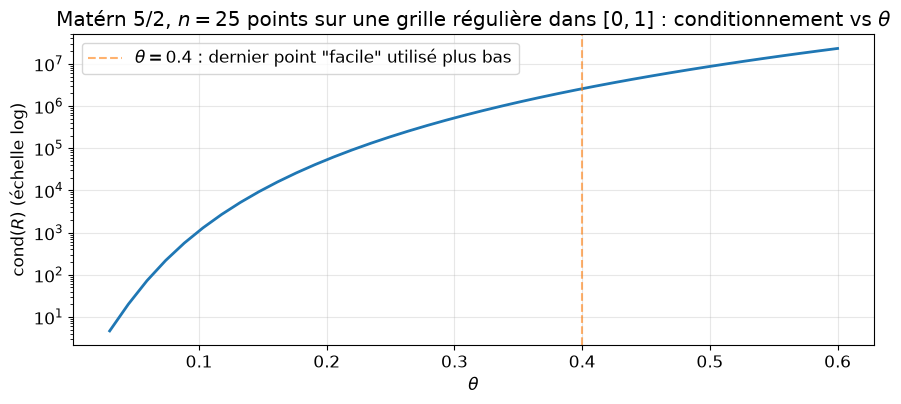

cond(R) pour theta=0.05 : 2.007e+01
cond(R) pour theta=0.20 : 6.196e+04
cond(R) pour theta=0.40 : 2.412e+06
cond(R) pour theta=0.60 : 2.314e+07

La double précision offre ~16 chiffres décimaux significatifs ; une fois cond(R) proche
de ~1e14-1e15, R est numériquement singulière quelle que soit la méthode -- Cholesky exact
et CG perdent tous les deux en précision pour la même raison (précision finie), juste de
façon visiblement différente : Cholesky peut encore renvoyer *un* facteur sans se plaindre,
CG signale honnêtement qu'il n'a pas pu atteindre la tolérance de résidu demandée.


In [2]:
def matern5_2(d, theta):
    r = np.abs(d) / theta
    s5 = np.sqrt(5.0)
    return (1 + s5 * r + 5 * r**2 / 3) * np.exp(-s5 * r)


n = 25
X = np.linspace(0.02, 0.98, n).reshape(-1, 1)


def f(x):
    return np.sin(6 * x) + 0.3 * x


y = f(X[:, 0]) + 0.03 * np.random.randn(n)

D = np.abs(X - X.T)
thetas_cond = np.linspace(0.03, 0.6, 40)
conds = []
for th in thetas_cond:
    w = np.linalg.eigvalsh(matern5_2(D, th))
    conds.append(w[-1] / w[0])

fig, ax = plt.subplots()
ax.semilogy(thetas_cond, conds, lw=2)
ax.axvline(0.4, color='C1', ls='--', alpha=0.6, label=r'$\theta=0.4$ : dernier point "facile" utilisé plus bas')
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$\mathrm{cond}(R)$ (échelle log)')
ax.set_title(f'Matérn 5/2, $n={n}$ points sur une grille régulière dans $[0,1]$ : conditionnement vs $\\theta$')
ax.legend()
plt.tight_layout()
plt.show()

print(f'cond(R) pour theta=0.05 : {conds[np.argmin(np.abs(thetas_cond-0.05))]:.3e}')
print(f'cond(R) pour theta=0.20 : {conds[np.argmin(np.abs(thetas_cond-0.20))]:.3e}')
print(f'cond(R) pour theta=0.40 : {conds[np.argmin(np.abs(thetas_cond-0.40))]:.3e}')
print(f'cond(R) pour theta=0.60 : {conds[np.argmin(np.abs(thetas_cond-0.60))]:.3e}')
print()
print('La double précision offre ~16 chiffres décimaux significatifs ; une fois cond(R) proche')
print("de ~1e14-1e15, R est numériquement singulière quelle que soit la méthode -- Cholesky exact")
print('et CG perdent tous les deux en précision pour la même raison (précision finie), juste de')
print('façon visiblement différente : Cholesky peut encore renvoyer *un* facteur sans se plaindre,')
print('CG signale honnêtement qu\'il n\'a pas pu atteindre la tolérance de résidu demandée.')

## 3. La vraisemblance itérative suit-elle vraiment la vraisemblance exacte ?

De vrais appels `pylibkriging` des deux côtés — `logLikelihoodFun`
(exact, `objective="LL"`) et `logLikelihoodIterativeFun`
(`objective="LLIterative(...)"`) — évalués sur une grille de valeurs de
$\theta$ pour les mêmes données, avec des réglages CG généreux
(`LLIterative(30,0,25,10,1e-6)` : 30 probes, pas de préconditionneur, 25
pas de Lanczos — le maximum utile ici puisque $n=25$ —, un budget de
$10n$ itérations, tolérance de résidu relatif $10^{-6}$) de sorte que la
convergence elle-même ne fasse aucun doute ici (vérifié ci-dessous via
`iterative_cg_n_unconverged()`) — tout écart restant entre les deux
courbes est donc bien l'approximation SLQ/Hutchinson du §1, pas un
artefact de précision de résolution linéaire. $\theta$ reste dans la
plage que le §2 a signalée comme numériquement confortable
($\mathrm{cond}(R) \lesssim 10^7$).

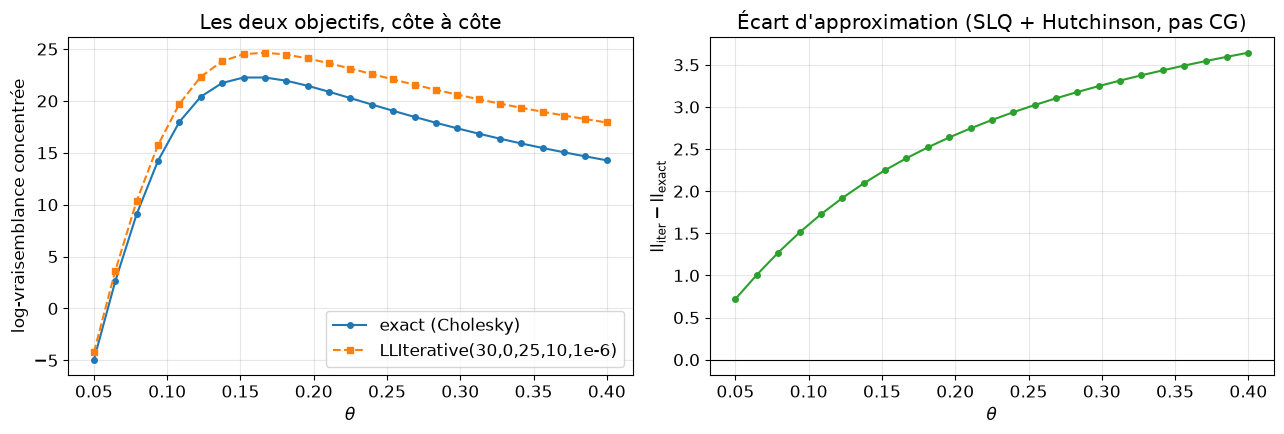

max n_unconverged sur le balayage : 0 (0 = chaque colonne, chaque theta, a bien convergé)
max |ll_iter - ll_exact| sur le balayage : 3.644
moyenne |ll_iter - ll_exact| sur le balayage : 2.621


In [3]:
theta_construct = np.array([[0.2]])
params = {'theta': theta_construct, 'is_theta_estim': False}

k_exact = lk.Kriging(y, X, 'matern5_2', regmodel='constant', objective='LL',
                     optim='none', parameters=params)
k_iter = lk.Kriging(y, X, 'matern5_2', regmodel='constant',
                    objective='LLIterative(30,0,25,10,1e-6)', optim='none', parameters=params)

thetas = np.linspace(0.05, 0.4, 25)
ll_exact = np.array([k_exact.logLikelihoodFun(np.array([th]), False, False)[0] for th in thetas]).ravel()
ll_iter = np.array([k_iter.logLikelihoodIterativeFun(np.array([th]), False)[0] for th in thetas]).ravel()
n_unconv = [k_iter.iterative_cg_n_unconverged() for th in thetas
           for _ in [k_iter.logLikelihoodIterativeFun(np.array([th]), False)]]

fig, (ax, ax_err) = plt.subplots(1, 2, figsize=(13, 4.5))
ax.plot(thetas, ll_exact, 'o-', label='exact (Cholesky)', ms=4)
ax.plot(thetas, ll_iter, 's--', label='LLIterative(30,0,25,10,1e-6)', ms=4)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel('log-vraisemblance concentrée')
ax.set_title('Les deux objectifs, côte à côte')
ax.legend()

ax_err.plot(thetas, ll_iter - ll_exact, 'o-', color='C2', ms=4)
ax_err.axhline(0, color='k', lw=0.8)
ax_err.set_xlabel(r'$\theta$')
ax_err.set_ylabel(r'$\mathrm{ll}_{\text{iter}} - \mathrm{ll}_{\text{exact}}$')
ax_err.set_title("Écart d'approximation (SLQ + Hutchinson, pas CG)")
plt.tight_layout()
plt.show()

print(f'max n_unconverged sur le balayage : {max(n_unconv)} (0 = chaque colonne, chaque theta, a bien convergé)')
print(f'max |ll_iter - ll_exact| sur le balayage : {np.max(np.abs(ll_iter-ll_exact)):.3f}')
print(f'moyenne |ll_iter - ll_exact| sur le balayage : {np.mean(np.abs(ll_iter-ll_exact)):.3f}')

## 4. Convergence de CG : ce n'est pas que $\mathrm{cond}(R)$, le second membre compte

C'est le fait empirique le plus important derrière les réglages de
`LLIterative` (`cg_tol` contre `probes_cg_tol`, plus bas) : **la vitesse
de convergence de CG dépend de la façon dont le second membre se projette
sur le spectre propre de $R$, pas seulement de $\mathrm{cond}(R)$.** Un
second membre lisse par rapport au plan d'expérience (comme les colonnes
de régression/réponse $F$, $y$) se concentre sur les modes propres
dominants et bien séparés de $R$, et converge vite. Un vecteur de
Rademacher isotrope (comme les probes de SLQ/Hutchinson) répartit son
énergie sur *tous* les modes, y compris les toutes petites valeurs
propres qui rendent $R$ mal conditionnée en premier lieu, et converge
bien plus lentement. Cela a été découvert à la dure en production — à
$n=8000$ (`bench/gpu`, `matern5_2`, $\theta=0.15$) la résolution des
probes a demandé **13470** itérations de CG contre **1100** pour
`[F|y]`, un écart de $12\times$ qui ne fait que grandir avec $n$ (voir le
tableau dans [Iterative.md](Iterative.md)).

La cellule ci-dessous reproduit le *mécanisme*, pas les chiffres de
production, avec une petite réimplémentation, entièrement commentée et
partant de zéro, de l'algorithme de CG groupé que fait tourner
`LinearAlgebra::conjugateGradientBatched` (produit matrice-vecteur en
lock-step sur toutes les colonnes du second membre, arrêt indépendant par
colonne, redémarrage à résidu exact tous les 50 itérations) — c'est du
**code illustratif pour ce notebook**, pas le solveur de production en
C++/CUDA, écrit pour exposer l'historique du résidu à chaque itération et
pouvoir le tracer directement (le solveur de production ne renvoie à
Python qu'un nombre d'itérations final, pas une trace pas-à-pas). Il est
vérifié contre une résolution dense directe avant d'être utilisé pour
quoi que ce soit ci-dessous.

cond(R) pour n=60, theta=0.25 : 3.65e+07
vérification (essai séparé, tolérance stricte, 3600 itérations) : max|CG - résolution directe| = 3.68e-03 (doit être petit)


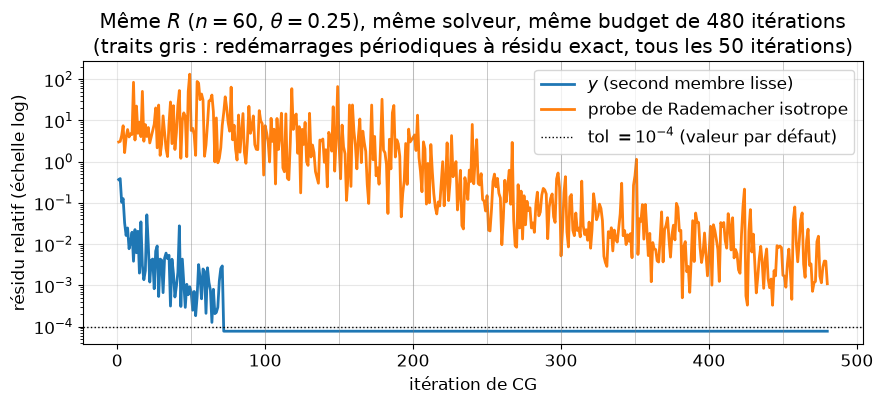

itérations pour atteindre relres < 0.0001 (budget = 480) :
  y (lisse) :          72
  probe isotrope :     jamais atteint -- résidu final = 1.09e-03


In [4]:
def cg_batched(Rmul, B, max_iter, tol, restart_every=50):
    # CG groupé illustratif avec redémarrage périodique à résidu exact --
    # même algorithme que LinearAlgebra::conjugateGradientBatched /
    # LinearAlgebraCuda::conjugateGradient, réécrit en numpy uniquement
    # pour exposer un historique de résidu par itération, à des fins de
    # tracé.
    n, ncols = B.shape
    Xsol = np.zeros_like(B)
    bnorm = np.linalg.norm(B, axis=0)
    bnorm[bnorm == 0] = 1.0
    R = B.copy()
    P = R.copy()
    rz_old = np.sum(R * R, axis=0)
    active = np.ones(ncols, dtype=bool)
    hist = []
    for it in range(max_iter):
        Ap = Rmul(P)
        pAp = np.sum(P * Ap, axis=0)
        alpha = np.where(active, np.divide(rz_old, pAp, out=np.zeros_like(rz_old), where=pAp != 0), 0.0)
        Xsol += alpha * P
        if (it + 1) % restart_every == 0:
            R_new = B - Rmul(Xsol)  # recalcul exact : corrige la dérive d'arrondi
        else:
            R_new = R - alpha * Ap  # mise à jour incrémentale, bon marché
        rr_new = np.sum(R_new * R_new, axis=0)
        relres = np.sqrt(rr_new) / bnorm
        active = active & (relres >= tol)
        hist.append(relres.copy())
        if not active.any():
            break
        beta = np.where(active, rr_new / np.where(rz_old == 0, 1.0, rz_old), 0.0)
        P = R_new + beta * P
        R = R_new
        rz_old = rr_new
    return Xsol, np.array(hist)


ncg = 60  # un n plus grand que l'exemple de vraisemblance ci-dessus : l'écart de
         # convergence lisse/isotrope a besoin de plus de place spectrale pour bien
         # se voir qu'avec n=25 (exemple SÉPARÉ et local -- ne réutilise ni n'écrase
         # X/y/D/n des sections précédentes)
Xcg = np.linspace(0.01, 0.99, ncg).reshape(-1, 1)
Dcg = np.abs(Xcg - Xcg.T)
theta_hard = 0.25
Rmat = matern5_2(Dcg, theta_hard)
Rmul = lambda V: Rmat @ V
print(f'cond(R) pour n={ncg}, theta={theta_hard} : {np.linalg.cond(Rmat):.2e}')

y_col = (np.sin(6 * Xcg[:, 0]) + 0.3 * Xcg[:, 0]).reshape(-1, 1)
rng = np.random.default_rng(0)
z_col = rng.choice([-1.0, 1.0], size=(ncg, 1))
B = np.hstack([y_col, z_col])

max_iter = 8 * ncg  # un budget généreux de 8n -- le réglage cg_max_iter_mult de LLIterative
Xsol, hist = cg_batched(Rmul, B, max_iter=max_iter, tol=1e-4, restart_every=50)

# Vérification contre une résolution dense directe, à tolérance bien plus stricte --
# ce CG illustratif doit résoudre le MÊME système que le code de production, pas
# juste "un" système. (cond(R) est assez grand ici pour qu'atteindre une tolérance
# STRICTE prenne bien plus d'itérations que le budget de 8n ci-dessus -- c'est en
# soi une instance du propos de cette section, pas une contradiction.)
Xsol_tight, _ = cg_batched(Rmul, B, max_iter=60 * ncg, tol=1e-8, restart_every=50)
Xtrue = np.linalg.solve(Rmat, B)
max_diff = np.abs(Xsol_tight - Xtrue).max()
print(f'vérification (essai séparé, tolérance stricte, {60*ncg} itérations) : '
     f'max|CG - résolution directe| = {max_diff:.2e} (doit être petit)')
assert max_diff < 0.05

fig, ax = plt.subplots()
it_axis = np.arange(1, hist.shape[0] + 1)
ax.semilogy(it_axis, hist[:, 0], label=r'$y$ (second membre lisse)', lw=2)
ax.semilogy(it_axis, hist[:, 1], label='probe de Rademacher isotrope', lw=2)
ax.axhline(1e-4, color='k', ls=':', lw=1, label=r'tol $=10^{-4}$ (valeur par défaut)')
for r in range(50, hist.shape[0], 50):
    ax.axvline(r, color='gray', lw=0.6, alpha=0.5)
ax.set_xlabel('itération de CG')
ax.set_ylabel('résidu relatif (échelle log)')
ax.set_title(rf'Même $R$ ($n={ncg}$, $\theta={theta_hard}$), même solveur, même budget de {max_iter} itérations'
             '\n(traits gris : redémarrages périodiques à résidu exact, tous les 50 itérations)')
ax.legend()
plt.tight_layout()
plt.show()

tol_ref = 1e-4
it_smooth = np.argmax(hist[:, 0] < tol_ref) + 1 if (hist[:, 0] < tol_ref).any() else None
it_iso = np.argmax(hist[:, 1] < tol_ref) + 1 if (hist[:, 1] < tol_ref).any() else None
print(f'itérations pour atteindre relres < {tol_ref} (budget = {max_iter}) :')
print(f'  y (lisse) :          {it_smooth if it_smooth else "jamais atteint"}')
print(f'  probe isotrope :     {it_iso if it_iso else f"jamais atteint -- résidu final = {hist[-1,1]:.2e}"}')

**Pourquoi c'est important pour les réglages.** Comme les probes de
Hutchinson (nécessaires au gradient) sont le second membre lent, et que
leur propre estimateur porte déjà un bruit d'échantillonnage en
$O(1/\sqrt{n_{\text{probe}}})$ (§5), il n'y a aucune raison de précision
de les résoudre à la même tolérance stricte que `[F|y]` — desserrer
*seulement* la tolérance des probes
(`objective="LLIterative(m,precond_rank,lanczos_steps,cg_max_iter_mult,cg_tol,probes_cg_tol)"`,
6ᵉ champ) récupère du temps de calcul réel, gratuitement. Mesuré
directement à $n=8000$ : `probes_cg_tol=1e-2` (contre `1e-4` par défaut,
partagé) a fait passer l'évaluation de 3,97 s à 1,71 s, avec une
précision du gradient **totalement inchangée**, parce que les deux
groupes de second membre sont désormais fusionnés en **une seule** passe
de Krylov (la fusion mBCG phase A de `LLIterative`, §6), qui laisse
chaque colonne s'arrêter à sa propre tolérance plutôt que de nécessiter
deux appels CG séparés à deux tolérances différentes.

**Pourquoi le redémarrage périodique compte.** La mise à jour
incrémentale du résidu, `R - alpha*Ap`, est bon marché mais accumule des
erreurs d'arrondi flottant ; non corrigée sur suffisamment d'itérations,
elle peut dériver du *vrai* résidu `B - Rmul(X)` au point de tromper le
critère d'arrêt. Tous les 50 itérations (traits gris ci-dessus), le
solveur recalcule au contraire le résidu exactement à partir du $X$
courant — un produit matrice-vecteur de plus, payé rarement, qui garde
tout le calcul numériquement honnête. C'est d'ailleurs ce même
redémarrage sur lequel s'appuie l'item #8 du plan (produit
matrice-vecteur en précision mixte) : les produits fp32/TF32 bon marché
accumulent une erreur *plus grande* entre deux redémarrages que le simple
arrondi fp64, et c'est le recalcul exact périodique qui la corrige — voir
`CHANGELOG.md` pour l'endroit où cela cesse de fonctionner (tolérances
très strictes).

## 5. Le log-déterminant stochastique : deux types d'erreur bien différents

L'écart d'approximation du §3 vient de deux sources vraiment
différentes, et les distinguer compte parce qu'elles répondent à des
réglages *différents* :

1. **Biais de troncature de Lanczos** (`lanczos_steps`, 20 par défaut) :
   la quadrature de Lanczos de chaque probe est une approximation
   *tronquée* de $z^\top\log(R)z$ qui devient exacte quand
   `lanczos_steps` $\to n$ (§1.5). Trop peu de pas résout mal le spectre
   de $R$ et biaise $\log|R|$ — une erreur **déterministe** pour un jeu
   de probes fixé, réductible en augmentant `lanczos_steps` (jusqu'au
   point de rendements décroissants, une fois la partie utile du spectre
   suffisamment résolue).
2. **Variance d'échantillonnage de Hutchinson** (`nprobe`, 1er champ de
   l'objectif, 30 par défaut) : même une quadrature de Lanczos
   parfaitement convergée par probe reste une estimation Monte-Carlo sur
   seulement $n_{\text{probe}}$ tirages d'une trace sur des vecteurs de
   Rademacher (§1.4) — une erreur **stochastique** qui décroît comme
   $O(1/\sqrt{n_{\text{probe}}})$, pas en résolvant quoi que ce soit plus
   précisément par probe.

Les deux graphiques ci-dessous fixent tout le reste à $\theta=0.35$
($\mathrm{cond}(R)\approx 10^{13}$ selon le §2 -- volontairement à
l'extrémité "difficile", où le biais de troncature est assez grand pour
bien se voir) et font varier un seul réglage à la fois, en comparant à la
vraisemblance exacte.

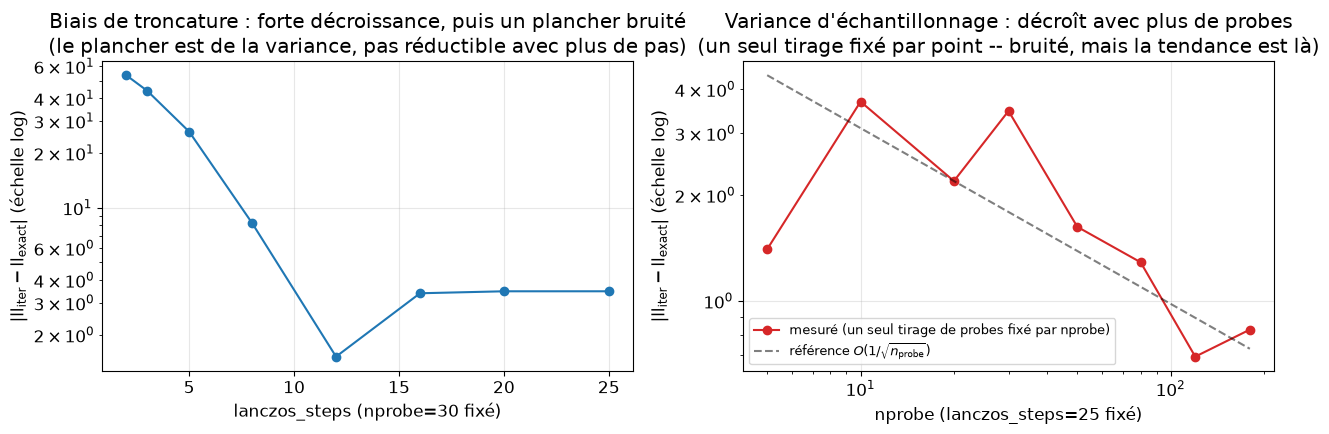

ll_exact pour theta=0.35 : 15.6468
balayage lanczos_steps : {2: 53.5633, 3: 43.9914, 5: 26.2028, 8: 8.2277, 12: 1.5149, 16: 3.3814, 20: 3.4672, 25: 3.4676}
balayage nprobe :        {5: 1.4024, 10: 3.6868, 20: 2.1915, 30: 3.4676, 50: 1.6233, 80: 1.2871, 120: 0.6937, 180: 0.8281}


In [5]:
theta_slq = 0.35
params_slq = {'theta': np.array([[theta_slq]]), 'is_theta_estim': False}
k_ex_slq = lk.Kriging(y, X, 'matern5_2', regmodel='constant', objective='LL',
                      optim='none', parameters=params_slq)
ll_ex_slq = float(k_ex_slq.logLikelihoodFun(np.array([theta_slq]), False, False)[0])

lanczos_steps_grid = [2, 3, 5, 8, 12, 16, 20, 25]
err_lanczos = []
for ls in lanczos_steps_grid:
    k = lk.Kriging(y, X, 'matern5_2', regmodel='constant',
                  objective=f'LLIterative(30,0,{ls},10,1e-6)', optim='none', parameters=params_slq)
    ll = float(k.logLikelihoodIterativeFun(np.array([theta_slq]), False)[0])
    err_lanczos.append(abs(ll - ll_ex_slq))

nprobe_grid = [5, 10, 20, 30, 50, 80, 120, 180]
err_nprobe = []
for npb in nprobe_grid:
    k = lk.Kriging(y, X, 'matern5_2', regmodel='constant',
                  objective=f'LLIterative({npb},0,25,10,1e-6)', optim='none', parameters=params_slq)
    ll = float(k.logLikelihoodIterativeFun(np.array([theta_slq]), False)[0])
    err_nprobe.append(abs(ll - ll_ex_slq))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.semilogy(lanczos_steps_grid, err_lanczos, 'o-', color='C0')
ax1.set_xlabel('lanczos_steps (nprobe=30 fixé)')
ax1.set_ylabel(r'$|\mathrm{ll}_{\text{iter}} - \mathrm{ll}_{\text{exact}}|$ (échelle log)')
ax1.set_title('Biais de troncature : forte décroissance, puis un plancher bruité\n(le plancher est de la variance, pas réductible avec plus de pas)')

ax2.loglog(nprobe_grid, err_nprobe, 'o-', color='C3', label='mesuré (un seul tirage de probes fixé par nprobe)')
ref = err_nprobe[2] * np.sqrt(nprobe_grid[2] / np.array(nprobe_grid, dtype=float))
ax2.loglog(nprobe_grid, ref, 'k--', alpha=0.5, label=r'référence $O(1/\sqrt{n_{\mathrm{probe}}})$')
ax2.set_xlabel('nprobe (lanczos_steps=25 fixé)')
ax2.set_ylabel(r'$|\mathrm{ll}_{\text{iter}} - \mathrm{ll}_{\text{exact}}|$ (échelle log)')
ax2.set_title('Variance d\'échantillonnage : décroît avec plus de probes\n(un seul tirage fixé par point -- bruité, mais la tendance est là)')
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'll_exact pour theta={theta_slq} : {ll_ex_slq:.4f}')
print('balayage lanczos_steps :', dict(zip(lanczos_steps_grid, [round(e,4) for e in err_lanczos])))
print('balayage nprobe :       ', dict(zip(nprobe_grid, [round(e,4) for e in err_nprobe])))

**En lisant les deux graphiques ensemble** : l'erreur du graphique
de gauche chute nettement de `lanczos_steps=2` jusque vers `12` (chaque
pas supplémentaire résout un peu plus du spectre de $R$), puis se stabilise
dans une bande bruitée que plus de pas ne réduit pas — parce que ce qui
reste est du bruit d'échantillonnage dû à un `nprobe` *fini* (graphique de
droite), pas de la troncature. Augmenter `lanczos_steps` au-delà du point
où le biais a plafonné ne fait plus rien pour l'erreur restante ; seul
plus de probes le fait. C'est exactement le constat de production à
$n=8000$ (le tableau `cg_tol` de `Iterative.md`) : huit ordres de grandeur
de précision de résolution linéaire *en plus* n'ont rien apporté à la
vraisemblance renvoyée, parce que le plancher de bruit SLQ/Hutchinson
dominait déjà. Resserrer le mauvais réglage est une erreur facile à
commettre avec cet objectif — vérifiez quelle source d'erreur domine
réellement (une comparaison rapide `LLIterative(m)` contre
`LLIterative(m,0,plus_de_pas)`, comme dans cette section) avant de
dépenser du budget d'itérations sur `cg_tol`.

## 6. Réutiliser la même passe de Krylov : la fusion mBCG, et où elle s'arrête

En production, `LLIterative` ne fait pas tourner séparément la
résolution CG de `[F|y]` et celle des probes de Hutchinson quand un
gradient est demandé — elles sont fusionnées en **une seule** passe de
Krylov groupée sur `[F|y|probes]`, puisqu'un produit matrice-vecteur
groupé partage déjà un même balayage de covariance entre toutes les
colonnes du bloc (§1.2 amortit déjà cela au sein de `[F|y]` ; la fusion
élargit simplement le bloc pour y inclure aussi les probes, chaque
colonne pouvant s'arrêter à *sa propre* tolérance grâce au vecteur de
tolérance par colonne déjà nécessaire au §4 pour `cg_tol` contre
`probes_cg_tol`). Réel, sûr, livré.

L'étape suivante, tentante — lire le log-déterminant SLQ directement sur
les coefficients $\alpha$/$\beta$ de ce *même* appel CG fusionné (la
dualité CG-Lanczos qui sous-tend le vrai "BBMM matrice-libre" : aucune
récurrence de Lanczos dédiée, zéro produit matrice-vecteur
supplémentaire) — a été essayée et volontairement **non conservée**. Une
vérification de la dualité elle-même, partant de zéro, s'est bien passée
(0,5 % d'erreur à $n=2000$, en fait *meilleure* que la Lanczos dédiée à
pas fixe qu'elle aurait remplacée), mais le redémarrage périodique de CG
en production (§4) fragmente la récurrence de Lanczos implicite en
segments indépendants, et reconstruire la quadrature à partir du seul
dernier segment s'est révélé dépendre de la pure chance — que le nombre
d'itérations nécessaire tombe près d'une frontière de redémarrage ou non
(50→237 % d'erreur, de signe faux ; 1000→0,1 % par un alignement
chanceux). Aucune des deux corrections évidentes n'est un correctif
rapide (combiner les segments risque un biais systématique ; desserrer la
cadence de redémarrage rouvre le risque de dérive d'arrondi qu'il existe
pour corriger, précisément là où c'est déjà documenté comme marginal).
Voir [MBCGLogDet.md](MBCGLogDet.md) pour l'investigation complète,
tableaux inclus, si vous êtes tenté de revenir dessus.

## 7. Le préconditionneur CG de Nystrom-Woodbury : réel, mais pas gratuit

`objective="LLIterative(m,precond_rank)"` fait passer chaque résolution
CG (et la quadrature SLQ elle-même, exécutée sur l'opérateur blanchi
$\tilde R = L^{-1}RL^{-\top}$ au lieu de $R$) par un préconditionneur de
Nystrom-Woodbury de rang `precond_rank`, construit à partir d'un jeu fixe
de points de référence ("landmarks") — même idée que les landmarks de
`LLNystrom` et l'option de préconditionnement de `predictIterative`. Un
$\tilde R$ mieux conditionné demande moins d'itérations de Krylov pour
la même tolérance, **et** resserre le biais SLQ (graphique de gauche du
§5) à `lanczos_steps` égal, puisque la quadrature résout désormais le
spectre plus doux de l'opérateur blanchi.

**Ce n'est pas automatiquement un gain**, d'où sa désactivation par
défaut (`precond_rank` omis ou 0). Contrairement à `predictIterative`
(préconditionné une fois, à un $\theta$ déjà ajusté), le
préconditionneur de `LLIterative` est reconstruit à partir des landmarks
fixes **au $\theta$ courant, à chaque évaluation d'objectif/gradient** —
un vrai coût de construction en $O(n\cdot\text{precond\_rank}^2)$, payé
à chaque fois que BFGS demande un nouveau $\theta$. Mesuré directement à
$n=8000$ : monter `precond_rank` à 256 a réduit le nombre d'itérations
de la résolution des probes (13470 → 7200) mais le coût de
reconstruction a plus que mangé le gain — le temps total a
*empiré* (3,97 s → 7,16 s). Que cela aide ou non dépend de la taille de
$n$ relativement au coût déjà payé par la résolution non préconditionnée
— ça vaut la peine d'essayer, pas de supposer.

## 8. Optimisations spécifiques GPU (bref renvoi)

Tout ce qui précède concerne la *méthode numérique* ; plusieurs
optimisations ajoutées depuis à ce projet changent *où tournent les
calculs*, pas ce qui est calculé, et sortent donc du cadre de ce notebook
(elles sont mesurées de façon exhaustive, avec des constats honnêtes
positifs et négatifs, dans `CHANGELOG.md` et `docs/math/Iterative.md`) :

- Un **chemin dense résident sur device** pour $R$/SLQ en CUDA
  (matérialiser $R$ une fois par évaluation, puis produits matrice-vecteur
  BLAS-3) — environ ×25 à ×114 à $n$ modéré.
- **Fusion mBCG phase A** (§6) — la moitié sûre de l'histoire de la
  dualité CG-Lanczos, ~17-24 % plus rapide en plus de ce qui précède.
- **Compaction de colonnes** dans le CG groupé — sortir une colonne déjà
  convergée de l'ensemble de travail au lieu de la trimballer dans chaque
  produit matrice-vecteur restant — environ ×7,4 spécifiquement sur le
  chemin matrice-libre (grand $n$, beaucoup de colonnes de second membre
  convergeant à des vitesses très différentes, exactement le phénomène du
  §4 à grande échelle) ; aucun effet sur le chemin dense (son produit
  matrice-vecteur est limité par la bande passante mémoire sur $R$
  lui-même, pas par le nombre de colonnes).
- Un **produit matrice-vecteur en précision mixte, optionnel** (TF32/fp32
  + correction périodique en fp64 au redémarrage, §4) — environ ×5 sur un
  GPU au fp64 bridé (L40S), ~×1,1 sur un GPU qui ne l'est pas (H100), avec
  un vrai plancher de précision aux tolérances strictes (documenté, pas
  caché).

Aucune de ces optimisations ne change la *valeur* de la vraisemblance
(identique au bit près, au bruit SLQ/Hutchinson près) — elles ne changent
que la vitesse à laquelle on l'obtient sur un backend donné.

## 9. `predictIterative` (un paragraphe, pas une section)

Une fois un modèle ajusté (peu importe comment), `predictIterative` est
un prédicteur matrice-libre *séparé*, non stochastique, construit sur la
même mécanique CG : une résolution CG par point de test (deux avec
`return_stdev`), aucune SLQ, aucun estimateur de Hutchinson. Il est
benchmarké en détail de son côté — exemple de correctitude travaillé,
passage à l'échelle mémoire/vitesse — dans
[predictiterative_vs_cholesky.ipynb](predictiterative_vs_cholesky.ipynb),
que ce notebook ne duplique volontairement pas.

## 10. Cholesky exact contre `LLIterative`, côte à côte

| | exact (`objective="LL"`) | `LLIterative` |
|---|---|---|
| $\hat\beta$/$\hat\sigma^2$/forme quadratique | exact (un seul facteur de Cholesky) | exact à `cg_tol` près (pas une approximation structurelle) |
| $\log\lvert R\rvert$ | exact | **stochastique** (SLQ) : biais de troncature (`lanczos_steps`) + variance d'échantillonnage (`nprobe`) |
| gradient | analytique exact | estimation de Hutchinson, indépendante de l'estimateur SLQ |
| déterminisme | totalement déterministe | déterministe **à probes fixées** (tirées une fois, réutilisées pour tout $\theta$ d'un même ajustement) |
| mémoire | facteur résident en $O(n^2)$ | $R$ n'a jamais besoin d'être résidente (matrice-libre), ou construite une fois et réutilisée (chemin dense rapide) si elle tient dans un budget |
| calcul par évaluation | $O(n^3)$ | $O(n^2)$ par produit matrice-vecteur CG/Lanczos $\times$ (itérations jusqu'à `cg_tol` + `lanczos_steps`) |
| mode de défaillance à $\mathrm{cond}(R)$ extrême | renvoie silencieusement *un* facteur (peut nécessiter un nugget numérique) | CG signale honnêtement la non-convergence (`iterative_cg_n_unconverged()`, un `[WARNING]`) |
| à utiliser quand | $n$ assez petit pour que $O(n^3)$/$O(n^2)$ soit abordable, et qu'on veuille la réponse de référence | $n$ assez grand pour qu'un facteur résident soit le vrai blocage, et qu'un log-déterminant stochastique à quelques pourcents près soit acceptable |

La ligne "mode de défaillance" mérite qu'on s'y attarde : un $R$ mal
conditionné est difficile pour *les deux* méthodes (§2), mais
`LLIterative` est celle qui vous le signale explicitement plutôt que de
renvoyer discrètement une réponse moins fiable.

## Conseils pratiques

- Commencez par les réglages par défaut (`objective="LLIterative(m)"`,
  $m\approx 30$ probes). Utilisez `lanczos_steps` (§5) si la *valeur* de
  la vraisemblance semble biaisée par rapport à un contrôle ponctuel avec
  l'objectif exact à un $\theta$ de confiance ; utilisez `probes_cg_tol`
  (§4) si les évaluations sont lentes et que c'est le gradient dont vous
  avez réellement besoin avec précision ; utilisez `precond_rank` (§7) si
  $n$ est assez grand pour que le nombre d'itérations de CG domine le
  coût — mais mesurez, ne supposez pas, car il a un vrai coût de mise en
  place, non négligeable.
- `NoiseModel::None` uniquement dans la version actuelle ;
  `simulate`/`update_simulate`/`save` sont bloqués sur les modèles ajustés
  avec `LLIterative` (aucune technique d'échantillonnage matrice-libre
  implémentée pour l'instant).
- `optim="none"` à $\theta$ fixé engage aussi un ajustement `LLIterative`
  léger (comme `LLNystrom` l'a toujours fait) — la façon rapide et
  déterministe d'obtenir un modèle façon `LLIterative` sans payer une
  recherche BFGS, utilisée partout dans ce notebook.
- Pour le volet performance de cette histoire (backends GPU, passage à
  l'échelle mémoire/temps avec $n$, l'historique complet de ce qui a été
  essayé et rejeté) voir `CHANGELOG.md` et [Iterative.md](Iterative.md) —
  ce notebook est volontairement centré sur les seules méthodes
  numériques.

## Références

- Ubaru, S., Chen, J., & Saad, Y. (2017). *Fast estimation of tr(f(A)) via
  stochastic Lanczos quadrature*. SIAM Journal on Matrix Analysis and
  Applications, 38(4), 1075-1099.
- Hutchinson, M. F. (1990). *A stochastic estimator of the trace of the
  influence matrix for Laplacian smoothing splines*. Communications in
  Statistics - Simulation and Computation, 19(2), 433-450.
- Gardner, J., Pleiss, G., Weinberger, K. Q., Bindel, D., & Wilson, A. G.
  (2018). *GPyTorch: Blackbox matrix-matrix Gaussian process inference
  with GPU acceleration*. Advances in Neural Information Processing
  Systems, 31 — la stratégie BBMM que cet objectif reprend.
- Hestenes, M. R., & Stiefel, E. (1952). *Methods of conjugate gradients
  for solving linear systems*. Journal of Research of the National Bureau
  of Standards, 49(6), 409-436 — la méthode CG originale sous-jacente à
  toute résolution matrice-libre utilisée ici.

Voir aussi [Iterative.md](Iterative.md) pour la référence complète de
l'API, [MBCGLogDet.md](MBCGLogDet.md) pour l'investigation de la phase B
de mBCG (§6), [PredictIterative.md](PredictIterative.md) pour le
prédicteur matrice-libre réutilisé ici, et
[Scalability.md](Scalability.md) pour la comparaison de `LLIterative`
avec `LLVecchia`, `LLNystrom`, `NestedKriging` et `subsetOfData`.